In [10]:
import os
import pickle
import torch
import pandas as pd
import numpy as np
import optuna
from datetime import datetime
import glob
from utils import parse_combination, create_model_with_dynamic_dims, mets_cols
from data_import import DataPreprocessor, DataLoaderManager
from MetS_prediction_model import train_sklearn_ensemble
from resampling import create_resampled_dataset
from feature_engineering import apply_to_all_data
from train_eval_function import train_model_with_loss
from data_import import SingleDietImpactDataset
from MetS_prediction_model import MultiDiseasePredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [11]:
data_path = '../data/total_again.xlsx'
data_processor = DataPreprocessor(data_path)

Device: cuda


In [12]:
train_df_global, val_df_global, test_df_global, _ = data_processor.process_all(
    normalize=True, selection_strategy='max_disease_change'
)
train_df_global, val_df_global, test_df_global, _ = apply_to_all_data(
    train_df_global, val_df_global, test_df_global
)

Initial data shape: (29098, 58)
Data shape after max disease change selection: (11238, 65)
Total unique patients: 11238
=== 피처 엔지니어링 시작 ===
✅ PCA 설명 분산비: 0.997
=== 피처 엔지니어링 완료 ===
상호작용 피처: 6개
PCA 피처: 10개
실제 change_dim: 6


### 1단계: 최고 방법 조합 찾기 -> best_combo

In [13]:
cache_file = '../result/best_combo/comprehensive_combo_cache.pkl'

try:
    with open(cache_file, 'rb') as f:
        cached_data = pickle.load(f)
    all_results = cached_data['all_results']
    best_combo = cached_data['best_combo']
    best_score = cached_data['best_score']
    sel_strategy, mod_method, resample_method, loss_method = best_combo
    print(f"캐시에서 불러온 최고 조합: {best_combo}, 점수: {best_score:.3f}")
    
    run_improved_loss = True  # True로 설정하면 자동 실행
    
except (FileNotFoundError, Exception):
    run_improved_loss = False
    
    selection_strategies = ['max_disease_change', 'first_last']
    model_methods = ['base', 'ensemble']
    resampling_methods = ['none', 'smote']
    
    loss_methods = [
        'CrossEntropy', 
        'FocalLoss', 
        'WeightedCE_log',
        'FocalLoss_gamma2.0',
        'FocalLoss_gamma2.5',
        'WeightedCE_inverse',
        'WeightedCE_effective',
        'WeightedCE_balanced'
    ]

    best_combo = None
    best_score = 0
    all_results = {}

    total_combinations = len(selection_strategies) * len(model_methods) * len(resampling_methods) * len(loss_methods)
    print(f"총 {total_combinations}개 조합 테스트 시작...")
    print(f"  선택 전략: {len(selection_strategies)}개")
    print(f"  모델 방법: {len(model_methods)}개")
    print(f"  리샘플링: {len(resampling_methods)}개")
    print(f"  손실 함수: {len(loss_methods)}개 (기본 3개 + 개선 5개)")

    combination_count = 0
    for sel_strategy in selection_strategies:
        for mod_method in model_methods:
            for resample_method in resampling_methods:
                for loss_method in loss_methods:
                    combination_count += 1
                    combo_name = f"{sel_strategy}_{mod_method}_{resample_method}_{loss_method}"
                    
                    print(f"\n[{combination_count}/{total_combinations}] {combo_name}")
                    
                    temp_train, temp_val, temp_test, _ = data_processor.process_all(
                        normalize=True, selection_strategy=sel_strategy
                    )
                    temp_train, temp_val, temp_test, actual_change_dim = apply_to_all_data(
                        temp_train, temp_val, temp_test
                    )
                    
                    temp_dataset = SingleDietImpactDataset(temp_train)
                    print(f"  피처 수: {len(temp_train.columns)}")
                    
                    if mod_method == 'ensemble':
                        disease = mets_cols[0]
                        result = train_sklearn_ensemble(temp_train, temp_val, temp_test, disease)
                        score = result['f1_score']
                    else:
                        model = create_model_with_dynamic_dims(temp_dataset, mets_cols).to(device)
                        
                        if resample_method == 'none':
                            train_loaders, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                                temp_train, temp_val, temp_test, batch_size=32)
                        else:
                            resampled_train = create_resampled_dataset(temp_train, resample_method)
                            train_loaders = {disease: torch.utils.data.DataLoader(
                                torch.utils.data.Subset(resampled_train, 
                                    [i for i, item in enumerate(resampled_train) if item['disease_name'] == disease]), 
                                batch_size=32, shuffle=True, drop_last=True) 
                                for disease in mets_cols}
                            _, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                                temp_train, temp_val, temp_test, batch_size=32)    
                        
                        disease = mets_cols[0]
                        
                        if loss_method in ['FocalLoss_gamma2.0', 'FocalLoss_gamma2.5', 
                                          'WeightedCE_inverse', 'WeightedCE_effective', 'WeightedCE_balanced']:
                            # 개선된 Loss 사용
                            from loss_functions import improved_loss_methods_configs
                            improved_configs = improved_loss_methods_configs(
                                {disease: train_loaders[disease]}, disease, device
                            )
                            
                            # 커스텀 학습 (기존 train_model_with_loss 대신)
                            criterion = improved_configs[loss_method]
                            
                            from MetS_prediction_model import EarlyStopping
                            optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=6e-4)
                            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                                optimizer, mode='min', factor=0.5, patience=5
                            )
                            early_stopping = EarlyStopping(patience=15, min_delta=0.001)
                            
                            for epoch in range(50):  # 빠른 테스트: 50 에폭
                                model.train()
                                for batch in train_loaders[disease]:
                                    optimizer.zero_grad()
                                    
                                    diet_data = batch['diet'].to(device)
                                    demo_data = batch['demo'].to(device)
                                    life_data = batch['life'].to(device)
                                    bio_data = batch['bio'].to(device)
                                    change_data = batch['delta'].to(device)
                                    inter_data = batch['interaction'].to(device)
                                    pca_data = batch['pca'].to(device)
                                    target = batch['target'].long().to(device).squeeze()
                                    
                                    outputs = model(diet_data, demo_data, life_data, bio_data, 
                                                  change_data, inter_data, pca_data, disease)
                                    loss = criterion(outputs['disease_logits'], target) + model.regularization_loss()
                                    loss.backward()
                                    optimizer.step()
                                
                                # Validation
                                model.eval()
                                val_loss = 0
                                val_count = 0
                                with torch.no_grad():
                                    for batch in val_loaders[disease]:
                                        diet_data = batch['diet'].to(device)
                                        demo_data = batch['demo'].to(device)
                                        life_data = batch['life'].to(device)
                                        bio_data = batch['bio'].to(device)
                                        change_data = batch['delta'].to(device)
                                        inter_data = batch['interaction'].to(device)
                                        pca_data = batch['pca'].to(device)
                                        target = batch['target'].long().to(device).squeeze()
                                        
                                        outputs = model(diet_data, demo_data, life_data, bio_data,
                                                      change_data, inter_data, pca_data, disease)
                                        val_loss += criterion(outputs['disease_logits'], target).item()
                                        val_count += 1
                                
                                val_loss_avg = val_loss / val_count
                                scheduler.step(val_loss_avg)
                                
                                if early_stopping(val_loss_avg, model):
                                    break
                            
                            early_stopping.load_best_model(model)
                            
                            # 평가
                            from train_eval_function import evaluate_model_custom
                            _, f1, _, _ = evaluate_model_custom(
                                model, test_loaders[disease], device, disease, 'deep'
                            )
                            score = f1
                            
                        else:
                            # 기존 Loss 사용
                            result = train_model_with_loss(
                                model, train_loaders[disease], val_loaders[disease], 
                                test_loaders[disease], disease, mod_method, loss_method
                            )
                            score = result['evaluation']['f1_score']
                        
                    print(f"  F1 점수: {score:.3f}")
                    all_results[combo_name] = score
                    
                    if score > best_score:
                        best_score = score
                        best_combo = (sel_strategy, mod_method, resample_method, loss_method)
                        print(f"  🎉 새로운 최고 점수! {score:.3f}")

    print(f"\n{'='*60}")
    print("최종 결과")
    print('='*60)
    print(f"최고 조합: {best_combo}")
    print(f"최고 점수: {best_score:.3f}")
    
    # 캐시 저장
    os.makedirs('../result/best_combo', exist_ok=True)
    cache_data = {
        'best_combo': best_combo,
        'best_score': best_score,
        'all_results': all_results
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)

    # 결과 저장
    results_list = []
    for combo_name, score in all_results.items():
        data_strategy, model_method, resample_method, loss_method = parse_combination(combo_name)
        results_list.append({
            '데이터_선택': data_strategy,
            '모델_방법': model_method,
            '리샘플링': resample_method,
            '손실함수': loss_method,
            'F1_점수': score
        })

    results_df = pd.DataFrame(results_list)
    results_df = results_df.sort_values('F1_점수', ascending=False).reset_index(drop=True)
    results_df.to_excel('../result/best_combo/combo_results.xlsx', index=False)
    
    sel_strategy, mod_method, resample_method, loss_method = best_combo

print(f"\n✅ 선택된 최고 조합:")
print(f"  📊 데이터 선택: {sel_strategy}")
print(f"  🤖 모델 방법: {mod_method}")
print(f"  ⚖️ 리샘플링: {resample_method}")
print(f"  📉 손실함수: {loss_method}")
print(f"  🎯 최고 점수: {best_score:.3f}")

# 개선된 Loss 상위 5개 출력
if 'all_results' in locals():
    print(f"\n📊 Loss 함수별 상위 5개:")
    sorted_results = sorted(all_results.items(), key=lambda x: x[1], reverse=True)[:5]
    for i, (combo, score) in enumerate(sorted_results, 1):
        print(f"  {i}. {combo}: {score:.3f}")

캐시에서 불러온 최고 조합: ('max_disease_change', 'base', 'smote', 'FocalLoss_gamma2.5'), 점수: 0.495

✅ 선택된 최고 조합:
  📊 데이터 선택: max_disease_change
  🤖 모델 방법: base
  ⚖️ 리샘플링: smote
  📉 손실함수: FocalLoss_gamma2.5
  🎯 최고 점수: 0.495

📊 Loss 함수별 상위 5개:
  1. max_disease_change_base_smote_FocalLoss_gamma2.5: 0.495
  2. max_disease_change_base_smote_CrossEntropy: 0.494
  3. max_disease_change_base_smote_WeightedCE_log: 0.483
  4. max_disease_change_base_smote_WeightedCE_balanced: 0.478
  5. max_disease_change_base_smote_WeightedCE_effective: 0.475


### 2단계: 하이퍼파라미터 최적화 -> optuna_study


2단계: Optuna 하이퍼파라미터 최적화
Optuna 결과 로드 완료: optuna_study_20260105.pkl
최고 점수: 0.502
최고 파라미터: {'dropout_rate': 0.30171169805272124, 'l1_lambda': 0.0002609447534967775, 'l2_lambda': 0.00025815754769703054}
총 시도 횟수: 30


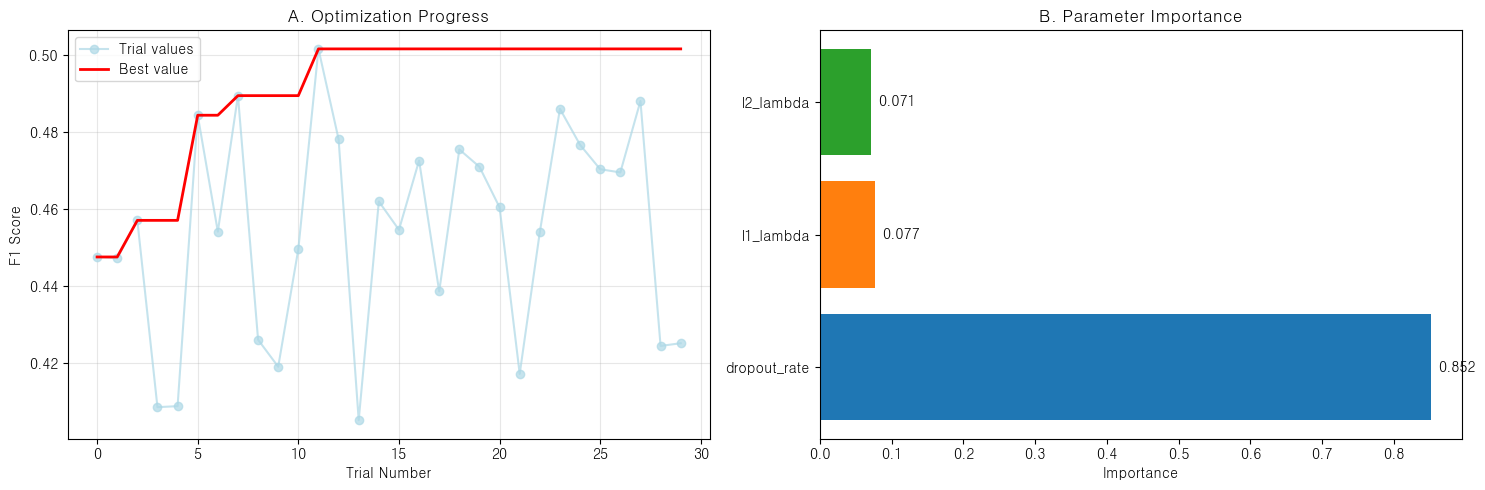

Total trials: 30
Best value: 0.5017
Best parameters: {'dropout_rate': 0.30171169805272124, 'l1_lambda': 0.0002609447534967775, 'l2_lambda': 0.00025815754769703054}
Recent improvement rate: -0.003529 per trial
→ Optimization may benefit from more trials

Optimization Statistics:
- Total trials completed: 30
- Failed trials: 0
- Best trial number: 11
- Optimization range: 0.4053 - 0.5017

✅ Optuna 최적화 완료!
   최고 F1: 0.502
   최적 파라미터: {'dropout_rate': 0.30171169805272124, 'l1_lambda': 0.0002609447534967775, 'l2_lambda': 0.00025815754769703054}


In [14]:
def load_optuna_results():
    study_dir = '../result/optuna_study'
    
    if not os.path.exists(study_dir):
        return None
    
    study_files = glob.glob(os.path.join(study_dir, 'optuna_study_*.pkl'))    
    if not study_files:
        return None
    
    latest_file = max(study_files, key=os.path.getmtime)
    with open(latest_file, 'rb') as f:
        study = pickle.load(f)
    
    print(f"Optuna 결과 로드 완료: {os.path.basename(latest_file)}")
    print(f"최고 점수: {study.best_value:.3f}")
    print(f"최고 파라미터: {study.best_params}")
    print(f"총 시도 횟수: {len(study.trials)}")
    
    return study

def create_efficient_train_loaders(resampled_train, diseases, batch_size):
    train_loaders = {}
    
    disease_indices = {}
    for i, item in enumerate(resampled_train):
        disease_name = item['disease_name']
        if disease_name not in disease_indices:
            disease_indices[disease_name] = []
        disease_indices[disease_name].append(i)
    
    for disease in diseases:
        if disease in disease_indices:
            indices = disease_indices[disease]
            subset = torch.utils.data.Subset(resampled_train, indices)
            train_loaders[disease] = torch.utils.data.DataLoader(
                subset, 
                batch_size=batch_size, 
                shuffle=True, 
                drop_last=True,
                num_workers=0
            )
        else:
            train_loaders[disease] = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(torch.empty(0)), 
                batch_size=batch_size
            )
    
    return train_loaders

def objective(trial, mod_method, resample_method, loss_method):
    try:
        batch_size = 16
        temp_train, temp_val, temp_test, _ = data_processor.process_all(
            normalize=True, selection_strategy=sel_strategy
        )
        temp_train, temp_val, temp_test, _ = apply_to_all_data(temp_train, temp_val, temp_test)

        if mod_method == 'ensemble':
            f1_scores = []
            for disease in mets_cols:
                result = train_sklearn_ensemble(temp_train, temp_val, temp_test, disease)
                f1_score = result['f1_score']
                f1_scores.append(f1_score)
            return np.mean(f1_scores)
        else:
            # 하이퍼파라미터 탐색 범위
            dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5)
            l1_lambda = trial.suggest_float('l1_lambda', 1e-4, 1e-3, log=True)
            l2_lambda = trial.suggest_float('l2_lambda', 1e-4, 1e-3, log=True)
            
            temp_dataset = SingleDietImpactDataset(temp_train)
            
            if resample_method == 'none':
                train_loaders, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                    temp_train, temp_val, temp_test, batch_size=batch_size)
            else:
                resampled_train = create_resampled_dataset(temp_train, resample_method)
                train_loaders = create_efficient_train_loaders(resampled_train, mets_cols, batch_size)                
                _, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                    temp_train, temp_val, temp_test, batch_size=batch_size)
            
            f1_scores = []
            disease = mets_cols[0]  # 첫 번째 질병만 테스트
            
            disease_model = create_model_with_dynamic_dims(
                temp_dataset, mets_cols, dropout_rate, l1_lambda, l2_lambda
            ).to(device)
            
            # Loss 함수 준비
            if loss_method in ['FocalLoss_gamma2.0', 'FocalLoss_gamma2.5', 
                              'WeightedCE_inverse', 'WeightedCE_effective', 'WeightedCE_balanced']:
                from loss_functions import improved_loss_methods_configs
                improved_configs = improved_loss_methods_configs(
                    {disease: train_loaders[disease]}, disease, device
                )
                criterion = improved_configs[loss_method]
                
                # 커스텀 학습
                from MetS_prediction_model import EarlyStopping
                optimizer = torch.optim.AdamW(disease_model.parameters(), lr=0.0001, weight_decay=6e-4)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=5
                )
                early_stopping = EarlyStopping(patience=15, min_delta=0.001)
                
                for epoch in range(50):  # Optuna는 빠르게
                    disease_model.train()
                    for batch in train_loaders[disease]:
                        optimizer.zero_grad()
                        
                        diet_data = batch['diet'].to(device)
                        demo_data = batch['demo'].to(device)
                        life_data = batch['life'].to(device)
                        bio_data = batch['bio'].to(device)
                        change_data = batch['delta'].to(device)
                        inter_data = batch['interaction'].to(device)
                        pca_data = batch['pca'].to(device)
                        target = batch['target'].long().to(device).squeeze()
                        
                        outputs = disease_model(diet_data, demo_data, life_data, bio_data,
                                              change_data, inter_data, pca_data, disease)
                        loss = criterion(outputs['disease_logits'], target) + disease_model.regularization_loss()
                        loss.backward()
                        optimizer.step()
                    
                    # Validation
                    disease_model.eval()
                    val_loss = 0
                    val_count = 0
                    with torch.no_grad():
                        for batch in val_loaders[disease]:
                            diet_data = batch['diet'].to(device)
                            demo_data = batch['demo'].to(device)
                            life_data = batch['life'].to(device)
                            bio_data = batch['bio'].to(device)
                            change_data = batch['delta'].to(device)
                            inter_data = batch['interaction'].to(device)
                            pca_data = batch['pca'].to(device)
                            target = batch['target'].long().to(device).squeeze()
                            
                            outputs = disease_model(diet_data, demo_data, life_data, bio_data,
                                                  change_data, inter_data, pca_data, disease)
                            val_loss += criterion(outputs['disease_logits'], target).item()
                            val_count += 1
                    
                    val_loss_avg = val_loss / val_count
                    scheduler.step(val_loss_avg)
                    
                    if early_stopping(val_loss_avg, disease_model):
                        break
                
                early_stopping.load_best_model(disease_model)
                
                # 평가
                from train_eval_function import evaluate_model_custom
                _, f1, _, _ = evaluate_model_custom(
                    disease_model, test_loaders[disease], device, disease, 'deep'
                )
                f1_scores.append(f1)
            else:
                # 기존 train_model_with_loss 사용
                result = train_model_with_loss(
                    disease_model, train_loaders[disease], val_loaders[disease], 
                    test_loaders[disease], disease, mod_method, loss_method
                )
                f1_scores.append(result['evaluation']['f1_score'])
            
            del disease_model, train_loaders, val_loaders, test_loaders
            if resample_method != 'none':
                del resampled_train
            torch.cuda.empty_cache()
            
            return np.mean(f1_scores)
            
    except Exception as e:
        print(f"Trial 실패: {e}")
        torch.cuda.empty_cache()
        return 0.0

# Optuna 실행
import matplotlib.pyplot as plt
from optuna.visualization import plot_optimization_history, plot_param_importances
import seaborn as sns

def create_figure1_visualization(study, save_path='../result/figures/figure1_optimization.png'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Optimization History
    ax1 = axes[0]
    trials_df = study.trials_dataframe()
    trial_numbers = trials_df.index
    values = trials_df['value']
    
    best_values = []
    current_best = -np.inf
    for val in values:
        if pd.notna(val) and val > current_best:
            current_best = val
        best_values.append(current_best)
    
    ax1.plot(trial_numbers, values, 'o-', alpha=0.7, color='lightblue', label='Trial values')
    ax1.plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best value')
    ax1.set_xlabel('Trial Number')
    ax1.set_ylabel('F1 Score')
    ax1.set_title('A. Optimization Progress')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Parameter Importance
    ax2 = axes[1]
    try:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())
        values = list(importance.values())
        
        bars = ax2.barh(params, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax2.set_xlabel('Importance')
        ax2.set_title('B. Parameter Importance')
        
        for i, (param, val) in enumerate(zip(params, values)):
            ax2.text(val + 0.01, i, f'{val:.3f}', va='center')
            
    except Exception as e:
        ax2.text(0.5, 0.5, f'Parameter importance\nnot available\n({str(e)})', 
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('B. Parameter Importance (N/A)')
        
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Total trials: {len(study.trials)}")
    print(f"Best value: {study.best_value:.4f}")
    print(f"Best parameters: {study.best_params}")
    
    return fig

def analyze_optimization_convergence(study):
    trials_df = study.trials_dataframe()    
    recent_trials = trials_df.tail(10)['value'].dropna()
    if len(recent_trials) > 1:
        improvement_rate = (recent_trials.iloc[-1] - recent_trials.iloc[0]) / len(recent_trials)
        print(f"Recent improvement rate: {improvement_rate:.6f} per trial")
        
        if abs(improvement_rate) < 0.001:
            print("✓ Optimization appears to have converged")
        else:
            print("→ Optimization may benefit from more trials")
    
    return trials_df

print("\n" + "="*70)
print("2단계: Optuna 하이퍼파라미터 최적화")
print("="*70)

existing_study = load_optuna_results()
if existing_study is not None:
    study = existing_study
    best_params = study.best_params
    
    # Figure 1 생성
    fig = create_figure1_visualization(study)
    
    # 수렴성 분석
    convergence_data = analyze_optimization_convergence(study)
    
    # 추가 통계
    print(f"\nOptimization Statistics:")
    print(f"- Total trials completed: {len([t for t in study.trials if t.value is not None])}")
    print(f"- Failed trials: {len([t for t in study.trials if t.value is None])}")
    print(f"- Best trial number: {study.best_trial.number}")
    print(f"- Optimization range: {min([t.value for t in study.trials if t.value is not None]):.4f} - {study.best_value:.4f}")
else:
    print("\n새로운 Optuna 최적화를 시작합니다.")
    print(f"조합: {sel_strategy}_{mod_method}_{resample_method}_{loss_method}")
    
    study = optuna.create_study(
        direction='maximize', 
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3)
    )

    study.optimize(
        lambda trial: objective(trial, mod_method, resample_method, loss_method), 
        n_trials=30, 
        show_progress_bar=True
    )

    date = datetime.now().strftime('%Y%m%d')
    os.makedirs('../result/optuna_study', exist_ok=True)
    with open(os.path.join('../result/optuna_study', f'optuna_study_{date}.pkl'), 'wb') as f:
        pickle.dump(study, f)

    best_params = study.best_params
    
    # Figure 생성
    fig = create_figure1_visualization(study)

print(f"\n✅ Optuna 최적화 완료!")
print(f"   최고 F1: {study.best_value:.3f}")
print(f"   최적 파라미터: {best_params}")


### 3단계: 최적 파라미터로 최종 평가 -> final_optimization

In [ ]:
sel_strategy = 'max_disease_change'
mod_method = 'base'
resample_method = 'smote'
loss_method = 'FocalLoss_gamma2.5'

best_params = {
    'dropout_rate': 0.30171169805272124,
    'l1_lambda': 0.0002609447534967775,
    'l2_lambda': 0.000258
}

best_combo = (sel_strategy, mod_method, resample_method, loss_method)

print("=" * 80)
print("Phase 3: 최종 전체 질병 평가")
print("=" * 80)
print(f"\n최적 설정:")
print(f"  - 데이터 선택: {sel_strategy}")
print(f"  - 모델 방법: {mod_method}")
print(f"  - 리샘플링: {resample_method}")
print(f"  - Loss 함수: {loss_method}")
print(f"  - Dropout: {best_params['dropout_rate']:.4f}")
print(f"  - L1 Lambda: {best_params['l1_lambda']:.6f}")
print(f"  - L2 Lambda: {best_params['l2_lambda']:.6f}")

save_dir = '../result/final_optimization'

if os.path.exists(os.path.join(save_dir, 'optimization_results.pkl')):
    print("\n기존 결과를 불러옵니다...")
    with open(os.path.join(save_dir, 'optimization_results.pkl'), 'rb') as f:
        optimization_results = pickle.load(f)
    
    final_results = optimization_results['final_results']
    best_combo = optimization_results['best_combination']
    best_params = optimization_results['best_hyperparams']
    avg_f1 = optimization_results['averages']['f1']
    avg_accuracy = optimization_results['averages']['accuracy']
    avg_roc_auc = optimization_results['averages']['roc_auc']
    avg_pr_auc = optimization_results['averages']['pr_auc']
    
    print(f"\n최종 결과 요약:")
    print(f"평균 F1 점수: {avg_f1:.3f}")
    print(f"평균 Accuracy: {avg_accuracy:.3f}")
    print(f"평균 ROC AUC: {avg_roc_auc:.3f}")
    print(f"평균 PR AUC: {avg_pr_auc:.3f}")
    print(f"사용된 방법: {mod_method}")
    print(f"최적 조합: {best_combo}")

    print(f"\n질병별 상세 성능:")
    for disease, metrics in final_results.items():
        print(f"  {disease}:")
        print(f"    F1: {metrics['f1_score']:.3f} | Acc: {metrics['accuracy']:.3f} | ROC: {metrics['roc_aucs']['Macro']:.3f} | PR: {metrics['pr_aucs']['Macro']:.3f}")
    
    print("\n하이퍼파라미터 최적화 완료! (기존 결과 사용)")
    
else:
    print("\n새로 학습을 시작합니다...")
    print(f"\n데이터 전처리 중...")
    final_train, final_val, final_test, _ = data_processor.process_all(
        normalize=True, 
        selection_strategy=sel_strategy
    )

    final_train, final_val, final_test, actual_change_dim = apply_to_all_data(
        final_train, final_val, final_test
    )
    
    print(f"  - Train: {len(final_train)}")
    print(f"  - Val: {len(final_val)}")
    print(f"  - Test: {len(final_test)}")

    final_results = {}
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if mod_method == 'ensemble':
        # Sklearn 앙상블 방법
        print(f"\nSklearn 앙상블 평가 중...")
        for disease in mets_cols:
            result = train_sklearn_ensemble(final_train, final_val, final_test, disease)
            final_results[disease] = result
            print(f"  {disease}: F1={result['f1_score']:.3f}, Acc={result['accuracy']:.3f}, ROC={result['roc_aucs']['Macro']:.3f}")
    
    else:
        print(f"\n딥러닝 모델 학습 중...")
        batch_size = 64
        dropout_rate = best_params['dropout_rate']
        l1_lambda = best_params['l1_lambda']
        l2_lambda = best_params['l2_lambda']
        
        # SMOTE 리샘플링 적용
        if resample_method == 'smote':
            print(f"  SMOTE 리샘플링 적용 중...")
            resampled_dataset = create_resampled_dataset(final_train, resample_method)
            
            # Train 로더 생성 (SMOTE 적용)
            train_loaders = create_efficient_train_loaders(resampled_dataset, mets_cols, batch_size)
            print(f"  - SMOTE 적용된 Train 로더 생성 완료")
            
            # Val/Test 로더 생성 (원본 데이터)
            _, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                final_train, final_val, final_test, batch_size=batch_size
            )
        
        else:
            # 리샘플링 없이 로더 생성
            train_loaders, val_loaders, test_loaders = DataLoaderManager.create_disease_loaders(
                final_train, final_val, final_test, batch_size=batch_size
            )
        
        # 데이터셋 차원 확인
        sample_batch = next(iter(train_loaders[mets_cols[0]]))
        diet_dim = sample_batch['diet'].shape[1]
        demo_dim = sample_batch['demo'].shape[1]
        life_dim = sample_batch['life'].shape[1]
        bio_dim = sample_batch['bio'].shape[1]
        change_dim = sample_batch['delta'].shape[1]
        inter_dim = sample_batch['interaction'].shape[1]
        pca_dim = sample_batch['pca'].shape[1]
        
        print(f"\n데이터 차원:")
        print(f"  - Diet: {diet_dim}, Demo: {demo_dim}, Life: {life_dim}, Bio: {bio_dim}")
        print(f"  - Delta: {change_dim}, Interaction: {inter_dim}, PCA: {pca_dim}")
        
        # Loss 함수 설정 (개선된 버전 사용)
        loss_configs = improved_loss_methods_configs(
            train_loaders, 
            mets_cols[0],  # 첫 번째 질병으로 초기화
            device
        )
        criterion = loss_configs[loss_method]
        print(f"\nLoss 함수 설정 완료: {loss_method}")
        
        # 각 질병별 학습
        for idx, disease in enumerate(mets_cols):
            print(f"\n{'='*60}")
            print(f"질병 {idx+1}/5: {disease}")
            print(f"{'='*60}")
            
            # 모델 생성
            model = MultiDiseasePredictor(
                diet_dim=diet_dim,
                demo_dim=demo_dim,
                life_dim=life_dim,
                bio_dim=bio_dim,
                change_dim=change_dim,
                inter_dim=inter_dim,
                pca_dim=pca_dim,
                disease_names=mets_cols,
                dropout_rate=dropout_rate,
                l1_lambda=l1_lambda,
                l2_lambda=l2_lambda
            ).to(device)
            
            # 학습 설정
            optimizer = torch.optim.AdamW(
                model.parameters(), 
                lr=1e-4, 
                weight_decay=6e-4
            )
            
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, 
                mode='min', 
                factor=0.5, 
                patience=5
            )
            
            early_stopping = EarlyStopping(patience=15, min_delta=0.001)
            
            # 학습 루프
            print(f"학습 시작...")
            train_loader = train_loaders[disease]
            val_loader = val_loaders[disease]
            test_loader = test_loaders[disease]
            
            for epoch in range(100):
                model.train()
                total_loss = 0
                batch_count = 0
                
                for batch in train_loader:
                    target = batch['target'].long().to(device).squeeze()
                    
                    optimizer.zero_grad()
                    
                    diet_data = batch['diet'].to(device)
                    demo_data = batch['demo'].to(device)
                    life_data = batch['life'].to(device)
                    bio_data = batch['bio'].to(device)
                    change_data = batch['delta'].to(device)
                    inter_data = batch['interaction'].to(device)
                    pca_data = batch['pca'].to(device)
                    
                    outputs = model(
                        diet_data, demo_data, life_data, bio_data, 
                        change_data, inter_data, pca_data, disease
                    )
                    
                    loss = criterion(outputs['disease_logits'], target) + model.regularization_loss()
                    
                    loss.backward()
                    optimizer.step()
                    
                    total_loss += loss.item()
                    batch_count += 1
                
                train_loss = total_loss / batch_count
                
                # Validation
                model.eval()
                val_total_loss = 0
                val_batch_count = 0
                
                with torch.no_grad():
                    for batch in val_loader:
                        diet_data = batch['diet'].to(device)
                        demo_data = batch['demo'].to(device)
                        life_data = batch['life'].to(device)
                        bio_data = batch['bio'].to(device)
                        change_data = batch['delta'].to(device)
                        inter_data = batch['interaction'].to(device)
                        pca_data = batch['pca'].to(device)
                        target = batch['target'].long().to(device).squeeze()
                        
                        outputs = model(
                            diet_data, demo_data, life_data, bio_data,
                            change_data, inter_data, pca_data, disease
                        )
                        
                        val_loss = criterion(outputs['disease_logits'], target)
                        val_total_loss += val_loss.item()
                        val_batch_count += 1
                
                val_loss_avg = val_total_loss / val_batch_count
                
                scheduler.step(val_loss_avg)
                
                if (epoch + 1) % 10 == 0:
                    print(f"  Epoch {epoch+1}/100 - Train Loss: {train_loss:.4f}, Val Loss: {val_loss_avg:.4f}")
                
                if early_stopping(val_loss_avg, model):
                    print(f"  조기 종료: Epoch {epoch+1}")
                    break
            
            # 최적 모델 로드
            early_stopping.load_best_model(model)
            
            # 평가
            accuracy, f1, roc_aucs, pr_aucs = evaluate_model_custom(
                model, test_loader, device, disease, 'deep'
            )
            
            final_results[disease] = {
                'accuracy': accuracy,
                'f1_score': f1,
                'roc_aucs': roc_aucs,
                'pr_aucs': pr_aucs,
                'method': 'deeplearning'
            }
            
            print(f"\n결과:")
            print(f"  - F1: {f1:.3f}")
            print(f"  - Accuracy: {accuracy:.3f}")
            print(f"  - ROC AUC: {roc_aucs['Macro']:.3f}")
            print(f"  - PR AUC: {pr_aucs['Macro']:.3f}")
            
            # 메모리 정리
            del model, optimizer, scheduler
            torch.cuda.empty_cache()

    avg_f1 = np.mean([result['f1_score'] for result in final_results.values()])
    avg_accuracy = np.mean([result['accuracy'] for result in final_results.values()])
    avg_roc_auc = np.mean([result['roc_aucs']['Macro'] for result in final_results.values()])
    avg_pr_auc = np.mean([result['pr_aucs']['Macro'] for result in final_results.values()])

    print("\n" + "=" * 80)
    print("최종 결과 요약")
    print("=" * 80)
    print(f"\n평균 F1 점수: {avg_f1:.3f}")
    print(f"평균 Accuracy: {avg_accuracy:.3f}")
    print(f"평균 ROC AUC: {avg_roc_auc:.3f}")
    print(f"평균 PR AUC: {avg_pr_auc:.3f}")
    print(f"사용된 방법: {mod_method}")
    print(f"최적 조합: {best_combo}")

    print(f"\n질병별 상세 성능:")
    for disease, metrics in final_results.items():
        print(f"  {disease}:")
        print(f"    F1: {metrics['f1_score']:.3f} | Acc: {metrics['accuracy']:.3f} | ROC: {metrics['roc_aucs']['Macro']:.3f} | PR: {metrics['pr_aucs']['Macro']:.3f}")

    os.makedirs(save_dir, exist_ok=True)

    # 상세 결과 저장
    detailed_results = []
    for disease, metrics in final_results.items():
        detailed_results.append({
            'Disease': disease,
            'F1_Score': f"{metrics['f1_score']:.3f}",
            'Accuracy': f"{metrics['accuracy']:.3f}",
            'ROC_AUC': f"{metrics['roc_aucs']['Macro']:.3f}",
            'PR_AUC': f"{metrics['pr_aucs']['Macro']:.3f}",
            'Method': metrics.get('method', mod_method)
        })

    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(os.path.join(save_dir, 'detailed_results.csv'), index=False)

    # 요약 결과 저장
    summary_results = {
        'Average_F1': f"{avg_f1:.3f}",
        'Average_Accuracy': f"{avg_accuracy:.3f}",
        'Average_ROC_AUC': f"{avg_roc_auc:.3f}",
        'Average_PR_AUC': f"{avg_pr_auc:.3f}",
        'Best_Combination': str(best_combo),
        'Model_Method': mod_method
    }
    summary_df = pd.DataFrame([summary_results])
    summary_df.to_csv(os.path.join(save_dir, 'summary_results.csv'), index=False)

    # 전체 최적화 결과 저장
    optimization_results = {
        'best_combination': best_combo,
        'best_hyperparams': best_params,
        'best_optuna_score': 0.5017,
        'final_results': final_results,
        'averages': {
            'f1': avg_f1, 
            'accuracy': avg_accuracy, 
            'roc_auc': avg_roc_auc, 
            'pr_auc': avg_pr_auc
        }
    }

    with open(os.path.join(save_dir, 'optimization_results.pkl'), 'wb') as f:
        pickle.dump(optimization_results, f)

    print(f"\n💾 결과 저장 완료:")
    print(f"  - {save_dir}/detailed_results.csv")
    print(f"  - {save_dir}/summary_results.csv")
    print(f"  - {save_dir}/optimization_results.pkl")
    
    print("\n" + "=" * 80)
    print("하이퍼파라미터 최적화 완료!")
    print("=" * 80)

print(avg_f1)

Phase 3: 최종 전체 질병 평가

최적 설정:
  - 데이터 선택: max_disease_change
  - 모델 방법: base
  - 리샘플링: smote
  - Loss 함수: FocalLoss_gamma2.5
  - Dropout: 0.3017
  - L1 Lambda: 0.000261
  - L2 Lambda: 0.000258

새로 학습을 시작합니다...

데이터 전처리 중...
Initial data shape: (29098, 58)
Data shape after max disease change selection: (11238, 65)
Total unique patients: 11238
=== 피처 엔지니어링 시작 ===
✅ PCA 설명 분산비: 0.997
=== 피처 엔지니어링 완료 ===
상호작용 피처: 6개
PCA 피처: 10개
실제 change_dim: 6
  - Train: 8990
  - Val: 1124
  - Test: 1124

딥러닝 모델 학습 중...
  SMOTE 리샘플링 적용 중...
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11
리샘플링에 사용할 차원: {'diet': 19, 'demo': 4, 'life': 3, 'bio': 11, 'delta': 22, 'interaction': 6, 'pca': 10}
  - SMOTE 적용된 Train 로더 생성 완료
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11
컬럼 순서 고정 완료 - diet:19, demo:4, life:3, bio:11

데이터 차원:
  - Diet: 19, Demo: 4, Life: 3, Bio: 11
  - Delta: 22, Interaction: 6, PCA: 10


NameError: name 'improved_loss_methods_configs' is not defined

In [ ]:
final_train, final_val, final_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
final_train, final_val, final_test, actual_change_dim = apply_to_all_data(final_train, final_val, final_test)

if resample_method == 'none':
    _, _, test_loaders = DataLoaderManager.create_disease_loaders(
        final_train, final_val, final_test, batch_size=32)
else:
    _, _, test_loaders = DataLoaderManager.create_disease_loaders(
        final_train, final_val, final_test, batch_size=32)

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
class_names = ['개선', '유지', '악화']
colors = ['#2E8B57', '#FF8C00', '#DC143C']

for col_idx, disease in enumerate(mets_cols):
    if disease in final_results and 'model' in final_results[disease]:
        model = final_results[disease]['model']
        test_loader = test_loaders[disease]
        
        # 예측 결과 수집
        all_pred, all_true, all_prob = [], [], []
        
        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                diet_data = batch['diet'].to(device)
                demo_data = batch['demo'].to(device)
                life_data = batch['life'].to(device)
                bio_data = batch['bio'].to(device)
                change_data = batch['delta'].to(device)
                inter_data = batch['interaction'].to(device)
                pca_data = batch['pca'].to(device)
                target = batch['target'].to(device).squeeze()
                
                outputs = model(diet_data, demo_data, life_data, bio_data, 
                              change_data, inter_data, pca_data, disease)
                pred = torch.argmax(outputs['disease_logits'], dim=1)
                prob = torch.softmax(outputs['disease_logits'], dim=1)
                
                all_pred.extend(pred.cpu().numpy())
                all_true.extend(target.cpu().numpy())
                all_prob.extend(prob.cpu().numpy())
        
        all_true = np.array(all_true)
        all_prob = np.array(all_prob)
        all_pred = np.array(all_pred)
        
        # 1. ROC Curve (첫 번째 행)
        ax_roc = axes[0, col_idx]
        for i in range(3):
            y_true_binary = (all_true == i).astype(int)
            y_prob_class = all_prob[:, i]
            
            if len(np.unique(y_true_binary)) > 1:
                fpr, tpr, _ = roc_curve(y_true_binary, y_prob_class)
                roc_auc = auc(fpr, tpr)
                ax_roc.plot(fpr, tpr, color=colors[i], lw=2, 
                           label=f'{class_names[i]} (AUC={roc_auc:.3f})')
        
        ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC - {disease.replace("_", " ")}')
        ax_roc.legend(loc="lower right", fontsize=8)
        ax_roc.grid(True, alpha=0.3)
        
        # 2. PR Curve (두 번째 행)
        ax_pr = axes[1, col_idx]
        for i in range(3):
            y_true_binary = (all_true == i).astype(int)
            y_prob_class = all_prob[:, i]
            
            if len(np.unique(y_true_binary)) > 1:
                precision, recall, _ = precision_recall_curve(y_true_binary, y_prob_class)
                pr_auc = auc(recall, precision)
                ax_pr.plot(recall, precision, color=colors[i], lw=2,
                          label=f'{class_names[i]} (AUC={pr_auc:.3f})')
        
        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title(f'PR Curve - {disease.replace("_", " ")}')
        ax_pr.legend(loc="lower left", fontsize=8)
        ax_pr.grid(True, alpha=0.3)
        
        # 3. Confusion Matrix (세 번째 행)
        ax_cm = axes[2, col_idx]
        cm = confusion_matrix(all_true, all_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        im = ax_cm.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
        ax_cm.set_title(f'Confusion Matrix\n{disease.replace("_", " ")}')
        
        thresh = cm_normalized.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax_cm.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2f})',
                          ha="center", va="center",
                          color="white" if cm_normalized[i, j] > thresh else "black",
                          fontsize=7)
        
        ax_cm.set_ylabel('True label')
        ax_cm.set_xlabel('Predicted label')
        ax_cm.set_xticks(range(3))
        ax_cm.set_yticks(range(3))
        ax_cm.set_xticklabels(['개선', '유지', '악화'])
        ax_cm.set_yticklabels(['개선', '유지', '악화'])

plt.tight_layout()
os.makedirs('../result/figures', exist_ok=True)
plt.savefig('../result/figures/figure2_roc_pr_confusion.png', dpi=300, bbox_inches='tight')
plt.show()


### 4단계: SHAP 분석 -> shap_analysis

In [ ]:
def analyze_feature_categories(category_importance):
    if not category_importance:
        return {}
        
    overall_categories = {}
    for cat_name in ['dietary', 'demographic', 'lifestyle', 'biomarker', 'temporal', 'engineered']:
        scores = [category_importance[disease][cat_name] for disease in category_importance.keys() 
                 if cat_name in category_importance[disease]]
        if scores:
            overall_categories[cat_name] = np.mean(scores)
        else:
            overall_categories[cat_name] = 0.0
    
    total_importance = sum(overall_categories.values())
    if total_importance == 0:
        return {}
        
    category_percentages = {cat: (score/total_importance)*100 for cat, score in overall_categories.items()}
    
    print("전체 평균 기여도:")
    for cat, percentage in sorted(category_percentages.items(), key=lambda x: x[1], reverse=True):
        cat_names = {'dietary': '식습관', 'biomarker': '생체지표', 'temporal': '시간적변화', 
                    'demographic': '인구통계', 'lifestyle': '생활습관', 'engineered': '엔지니어링'}
        print(f"  {cat_names.get(cat, cat)}: {percentage:.1f}%")
    
    return category_percentages

def save_results(results, category_importance, feature_names):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    save_dir = f'../result/shap_analysis/{timestamp}'
    os.makedirs(save_dir, exist_ok=True)
    
    with open(os.path.join(save_dir, 'shap_results.pkl'), 'wb') as f:
        pickle.dump({'results': results, 'category_importance': category_importance, 
                    'feature_names': feature_names}, f)
    
    importance_data = []
    for disease, result in results.items():
        for i, importance in enumerate(result['overall_importance']):
            if i < len(result['feature_names']):
                importance_data.append({
                    'Disease': disease,
                    'Feature': result['feature_names'][i],
                    'Importance': importance,
                    'Category': get_feature_category(i)
                })
    
    importance_df = pd.DataFrame(importance_data)
    importance_df.to_csv(os.path.join(save_dir, 'feature_importance.csv'), index=False)
    
    category_df = pd.DataFrame(category_importance).T
    category_df.to_csv(os.path.join(save_dir, 'category_importance.csv'))
    
    print(f"\n결과 저장됨: {save_dir}")
    return save_dir

def get_feature_category(index):
    if index < 19: return 'dietary'
    elif index < 23: return 'demographic'  
    elif index < 26: return 'lifestyle'
    elif index < 37: return 'biomarker'
    elif index < 59: return 'temporal'
    else: return 'engineered'

In [ ]:
# 4단계 SHAP 분석 수정 버전
import shap
from SHAP import load_existing_shap_results, load_trained_model_and_data, extract_features_and_targets, create_model_wrapper

results, category_importance, feature_names = load_existing_shap_results()

if results is None:
    print("기존 SHAP 결과 없음. 새로 분석을 수행합니다.")
    
    # actual_change_dim을 먼저 얻기 위해 데이터 처리
    temp_train, temp_val, temp_test, _ = data_processor.process_all(normalize=True, selection_strategy=sel_strategy)
    temp_train, temp_val, temp_test, actual_change_dim = apply_to_all_data(temp_train, temp_val, temp_test)
    
    # 데이터셋 객체 생성
    temp_dataset = SingleDietImpactDataset(temp_train)
    
    # 이제 dataset 객체를 전달
    model, train_df, _, _, _, _, test_loaders, mets_cols = load_trained_model_and_data(best_combo, best_params, temp_dataset)

    feature_names = train_df.columns.tolist()
    feature_categories = {
        'dietary': list(range(19)),
        'demographic': list(range(19, 23)),
        'lifestyle': list(range(23, 26)),
        'biomarker': list(range(26, 37)),
        'temporal': list(range(37, 37+actual_change_dim)),
        'engineered': list(range(37+actual_change_dim, len(feature_names)-5))
    }
    
    results = {}
    category_importance = {}
    
    for disease_name in mets_cols:
        X_test, y_test = extract_features_and_targets(test_loaders[disease_name], disease_name)
        
        n_samples = min(100, len(X_test))
        indices = np.random.choice(len(X_test), n_samples, replace=False)
        X_sample = X_test[indices]
        
        n_background = min(50, len(X_sample))
        X_background = X_sample[:n_background]
        
        n_explain = min(20, len(X_sample))
        X_explain = X_sample[:n_explain]
        
        # dataset 객체를 전달
        model_wrapper = create_model_wrapper(model, disease_name, temp_dataset)
        
        explainer = shap.Explainer(model_wrapper, X_background)
        shap_values = explainer(X_explain)
        
        importance_improve = np.mean(np.abs(shap_values.values[:, :, 0]), axis=0)
        importance_maintain = np.mean(np.abs(shap_values.values[:, :, 1]), axis=0)  
        importance_worsen = np.mean(np.abs(shap_values.values[:, :, 2]), axis=0)
        
        overall_importance = (importance_improve + importance_maintain + importance_worsen) / 3
        
        results[disease_name] = {
            'shap_values': shap_values,
            'importance_improve': importance_improve,
            'importance_maintain': importance_maintain, 
            'importance_worsen': importance_worsen,
            'overall_importance': overall_importance,
            'feature_names': feature_names[:len(overall_importance)]
        }
        
        cat_importance = {}
        for cat_name, indices in feature_categories.items():
            valid_indices = [i for i in indices if i < len(overall_importance)]
            if valid_indices:
                cat_importance[cat_name] = np.mean([overall_importance[i] for i in valid_indices])
            else:
                cat_importance[cat_name] = 0.0
        
        category_importance[disease_name] = cat_importance
        print(f"  {disease_name}: SHAP 분석 완료")
else:
    print("기존 SHAP 결과를 사용합니다.")

category_percentages = analyze_feature_categories(category_importance)
if category_importance:
    print("\n=== 주요 발견사항 ===")
    print(f"식습관 요인 기여도: {category_percentages.get('dietary', 0):.1f}%")
    print(f"생체지표 기여도: {category_percentages.get('biomarker', 0):.1f}%") 
    print(f"시간적변화 기여도: {category_percentages.get('temporal', 0):.1f}%")
    print(f"인구통계 기여도: {category_percentages.get('demographic', 0):.1f}%")
    print(f"생활습관 기여도: {category_percentages.get('lifestyle', 0):.1f}%")
    print(f"엔지니어링 기여도: {category_percentages.get('engineered', 0):.1f}%")

if 'feature_categories' in locals():
    save_dir = save_results(results, category_importance, feature_names)
    print(f"새로운 결과 저장됨: {save_dir}")

### 5단계: 추천 모델

In [ ]:
from diet_recommend import DietaryRecommendationSystem

In [ ]:
final_test = test_df_global.copy()

# 모델 로딩 부분 수정
try:
    best_disease = max(final_results.keys(), key=lambda k: final_results[k]['f1_score'])
    print(f"선택된 질병: {best_disease} (F1: {final_results[best_disease]['f1_score']:.3f})")
    
    model_path = os.path.join('../result/final_optimization', 'final_best_models.pth')
    if os.path.exists(model_path):
        saved_models = torch.load(model_path, map_location=device)
        trained_model = saved_models[best_disease]
        
        recommender = DietaryRecommendationSystem(trained_model=trained_model, device=device)
        print("추천 시스템 준비 완료")
    else:
        print("저장된 모델을 찾을 수 없습니다.")
        recommender = None
        
except Exception as e:
    print(f"모델 로딩 중 오류: {e}")
    recommender = None


In [ ]:
sample_index = 0
sample_patient = final_test.iloc[sample_index]

# disease delta 컬럼들 정의
disease_delta_cols = [f'{disease}_delta' for disease in mets_cols]

# delta 컬럼 제외하고 피처 추출
patient_features = sample_patient.drop([col for col in sample_patient.index if col in disease_delta_cols]).values

print(f"\n=== {sample_index+1}번째 환자 추천 ===")
print(f"환자 피처 차원: {len(patient_features)}")

targets = {best_disease: 'improve'}

recommendations = recommender.generate_recommendations(
    patient_features=patient_features,
    targets=targets,
    max_change=1.5,
    method='optimization'
)

# 결과 출력
if 'error' in recommendations:
    print(f"오류: {recommendations['error']}")
else:
    print(f"총 {recommendations['total_changes']}개 식습관 변경 권장")
    print(f"실행 가능성: {recommendations['feasibility_score']:.1%}")
    
    if recommendations['recommendations']:
        print("\n식습관 권장사항:")
        for food, rec in recommendations['recommendations'].items():
            print(f"  • {rec['recommendation']}")
    
    print(f"\n예상 효과:")
    for disease, effect in recommendations['predicted_effects'].items():
        current = effect['current_improve_prob']
        predicted = effect['predicted_improve_prob']
        change = effect['improvement_change']
        print(f"  {disease}: {current:.1%} → {predicted:.1%} ({change:+.1%})")

In [ ]:
def evaluate_recommendation_system(recommender, rec_method, test_data, targets, n_patients=50):
    if recommender is None:
        print("추천 시스템이 준비되지 않았습니다.")
        return {}
        
    print(f"=== 추천 시스템 평가 ({n_patients}명 대상) ===")
    
    results = {
        'improvement_predictions': [],
        'feasibility_scores': [],
        'recommendation_counts': [],
        'consistency_scores': [],
        'diversity_scores': []
    }
    
    # disease delta 컬럼들 정의
    disease_delta_cols = [f'{disease}_delta' for disease in mets_cols]
    
    try:
        # 1. 개선 효과 시뮬레이션
        print("1. 개선 효과 시뮬레이션...")
        improvement_count = 0
        
        for i in range(min(n_patients, len(test_data))):
            patient_data = test_data.iloc[i]
            features = patient_data.drop([col for col in patient_data.index 
                                        if col in disease_delta_cols]).values
            
            rec = recommender.generate_recommendations(
                patient_features=features,
                targets=targets,
                max_change=1.0,
                method=rec_method
            )
            
            if 'error' not in rec:
                for disease, effect in rec['predicted_effects'].items():
                    improvement_change = effect['improvement_change']
                    results['improvement_predictions'].append(improvement_change)
                    if improvement_change > 0.05:
                        improvement_count += 1
                
                results['feasibility_scores'].append(rec['feasibility_score'])
                results['recommendation_counts'].append(rec['total_changes'])
        
        # 결과 요약
        if results['improvement_predictions']:
            avg_improvement = np.mean(results['improvement_predictions'])
            improvement_rate = improvement_count / len(results['improvement_predictions'])
            print(f"평균 개선 예상 효과: {avg_improvement:.1%}")
            print(f"개선 예상 비율: {improvement_rate:.1%}")
        
        if results['feasibility_scores']:
            avg_feasibility = np.mean(results['feasibility_scores'])
            print(f"평균 실행 가능성: {avg_feasibility:.1%}")
        
        if results['recommendation_counts']:
            avg_changes = np.mean(results['recommendation_counts'])
            print(f"평균 추천 식품 수: {avg_changes:.1f}개")
            
    except Exception as e:
        print(f"평가 중 오류: {e}")
    
    return results

In [ ]:
targets = {best_disease: 'improve'}
evaluation_results = evaluate_recommendation_system(
    recommender, 'optimization', final_test, targets, n_patients=20
)
